# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_daily_pred,
    plot_feature_importances,
)
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    convert_to_serializable,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-15 18:03:50.902 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 250
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_TOP_K = 35
FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_optuna"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
)
print_best_params(study)

[I 2026-01-15 18:03:55,738] A new study created in memory with name: no-name-fd1c225b-3d44-4fec-9608-4d11ff746a8f
[I 2026-01-15 18:04:09,650] Trial 5 finished with value: 1.0241995536551718 and parameters: {'num_leaves': 26, 'max_depth': 3, 'learning_rate': 0.05857747269911269, 'n_estimators': 141, 'subsample': 0.5961763958848793, 'colsample_bytree': 0.5021789231055851, 'min_child_samples': 13, 'reg_alpha': 8.366662960174246, 'reg_lambda': 8.596267629195811}. Best is trial 5 with value: 1.0241995536551718.
[I 2026-01-15 18:04:16,501] Trial 0 finished with value: 0.9897287163569699 and parameters: {'num_leaves': 31, 'max_depth': 5, 'learning_rate': 0.15089123667632776, 'n_estimators': 174, 'subsample': 0.6246247191679881, 'colsample_bytree': 0.7591924015853254, 'min_child_samples': 23, 'reg_alpha': 6.164185731657961, 'reg_lambda': 9.655124449452805}. Best is trial 0 with value: 0.9897287163569699.
[I 2026-01-15 18:04:16,840] Trial 4 finished with value: 1.0753846023211375 and parameters

Best parameters: {'num_leaves': 19, 'max_depth': 4, 'learning_rate': 0.09959155544614456, 'n_estimators': 209, 'subsample': 0.6115913831354504, 'colsample_bytree': 0.8248131002151441, 'min_child_samples': 16, 'reg_alpha': 2.1424279101931667, 'reg_lambda': 2.73096797360692}
Best score: 0.98128


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
33,"{'num_leaves': 19, 'max_depth': 4, 'learning_r...",0.299826,0.981284,-0.769626,-0.797675,-1.527670,-1.080383,-0.731067,1
22,"{'num_leaves': 9, 'max_depth': 3, 'learning_ra...",0.295724,0.982277,-0.780026,-0.802805,-1.515971,-1.090371,-0.722213,2
19,"{'num_leaves': 18, 'max_depth': 4, 'learning_r...",0.299774,0.983308,-0.762723,-0.803496,-1.521726,-1.099923,-0.728674,3
43,"{'num_leaves': 20, 'max_depth': 5, 'learning_r...",0.306319,0.984216,-0.759808,-0.802512,-1.541186,-1.087934,-0.729641,4
32,"{'num_leaves': 25, 'max_depth': 4, 'learning_r...",0.300298,0.984257,-0.774876,-0.800725,-1.528980,-1.088799,-0.727905,5


### SHAP feature selection

In [8]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [9]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
)
print_best_params(study)

[I 2026-01-15 18:07:00,590] A new study created in memory with name: no-name-b7c76745-8a12-4353-9187-e2777a649c05
[I 2026-01-15 18:07:09,987] Trial 1 finished with value: 1.0099550255429026 and parameters: {'num_leaves': 12, 'max_depth': 3, 'learning_rate': 0.06590589846535384, 'n_estimators': 141, 'subsample': 0.6084337381016831, 'colsample_bytree': 0.9306745268363823, 'min_child_samples': 30, 'reg_alpha': 8.94990001342247, 'reg_lambda': 7.507883870000082, 'keep_count': 38}. Best is trial 1 with value: 1.0099550255429026.
[I 2026-01-15 18:07:12,607] Trial 3 finished with value: 1.1010537014055455 and parameters: {'num_leaves': 9, 'max_depth': 5, 'learning_rate': 0.014306141618770965, 'n_estimators': 210, 'subsample': 0.5237647716646678, 'colsample_bytree': 0.5035130941342199, 'min_child_samples': 17, 'reg_alpha': 2.098580251092845, 'reg_lambda': 3.0452970480078516, 'keep_count': 10}. Best is trial 1 with value: 1.0099550255429026.
[I 2026-01-15 18:07:13,849] Trial 0 finished with valu

Best parameters: {'num_leaves': 24, 'max_depth': 5, 'learning_rate': 0.19023509491519933, 'n_estimators': 174, 'subsample': 0.8543410818728239, 'colsample_bytree': 0.8805059700387299, 'min_child_samples': 10, 'reg_alpha': 5.071847302119691, 'reg_lambda': 7.086731806425419, 'keep_count': 15}
Best score: 0.96858


In [16]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
148,"{'num_leaves': 24, 'max_depth': 5, 'learning_r...",0.291827,0.968579,-0.765421,-0.801546,-1.509354,-1.040855,-0.725719,1
141,"{'num_leaves': 23, 'max_depth': 5, 'learning_r...",0.293892,0.968871,-0.763766,-0.808501,-1.513708,-1.039104,-0.719278,2
242,"{'num_leaves': 21, 'max_depth': 5, 'learning_r...",0.277830,0.969148,-0.758811,-0.799121,-1.466720,-1.081350,-0.739739,3
167,"{'num_leaves': 20, 'max_depth': 5, 'learning_r...",0.294749,0.969544,-0.756833,-0.807052,-1.516760,-1.039257,-0.727819,4
147,"{'num_leaves': 20, 'max_depth': 5, 'learning_r...",0.288457,0.969842,-0.770861,-0.812322,-1.505100,-1.037234,-0.723694,5


### Scores

In [17]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8360
MAE:  6.6191
R2:   0.6431


In [18]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.73395842e+01 1.30440661e+01 8.07128723e+00 7.05984952e+00
 3.53977250e+00 2.01682952e+01 1.37537503e+01 4.29966424e+01
 3.25620899e+01 7.24660561e+00 3.31264757e+01 3.11260612e+00
 1.88416979e+01 2.93806787e+01 1.47431587e+01 9.32996542e+00
 0.00000000e+00 7.01702205e+00 2.65873705e+00 2.96291755e+01
 1.97727967e+01 3.96493965e+01 6.49860935e+00 1.20977739e+01
 8.27865383e+00 1.67108959e+01 4.04413502e+00 9.75325327e+00
 7.50620793e+00 2.58797666e+01 0.00000000e+00 4.14186089e+01
 2.52068112e+01 6.34437889e+00 4.71241027e-01 2.32448376e+01
 7.81490785e+00 3.15073531e+00 1.15835717e+01 1.06536341e+01
 1.08951213e+00 6.51220004e+00 1.36620341e+01 5.28104132e+00
 0.00000000e+00 1.84763739e+01 9.32455937e+00 3.78270

In [19]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8334
MAE:  7.1449
R2:   0.5543


## Graphs

## SHAP explanation

In [24]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

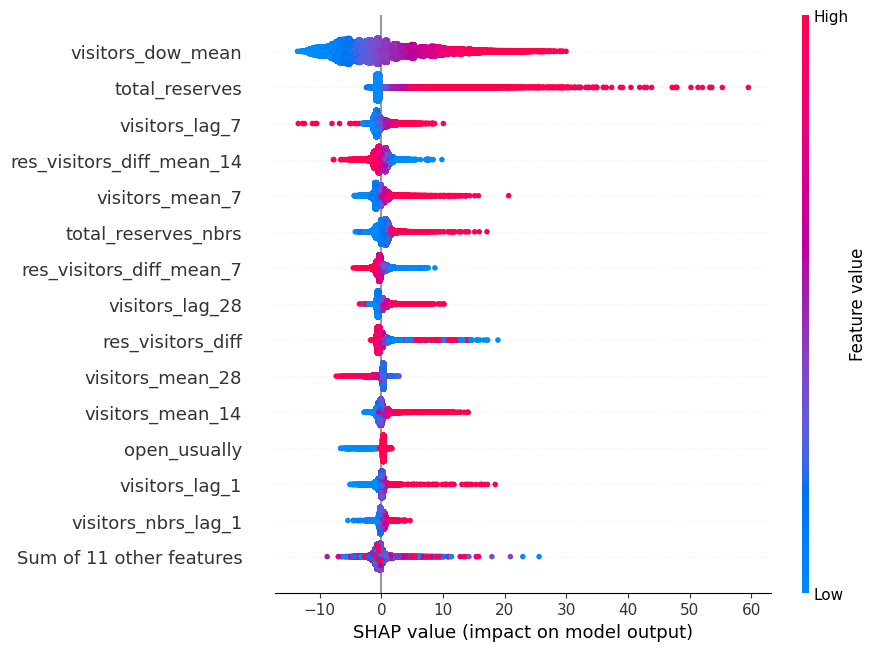

In [25]:
shap.plots.beeswarm(shap_values, max_display=15)

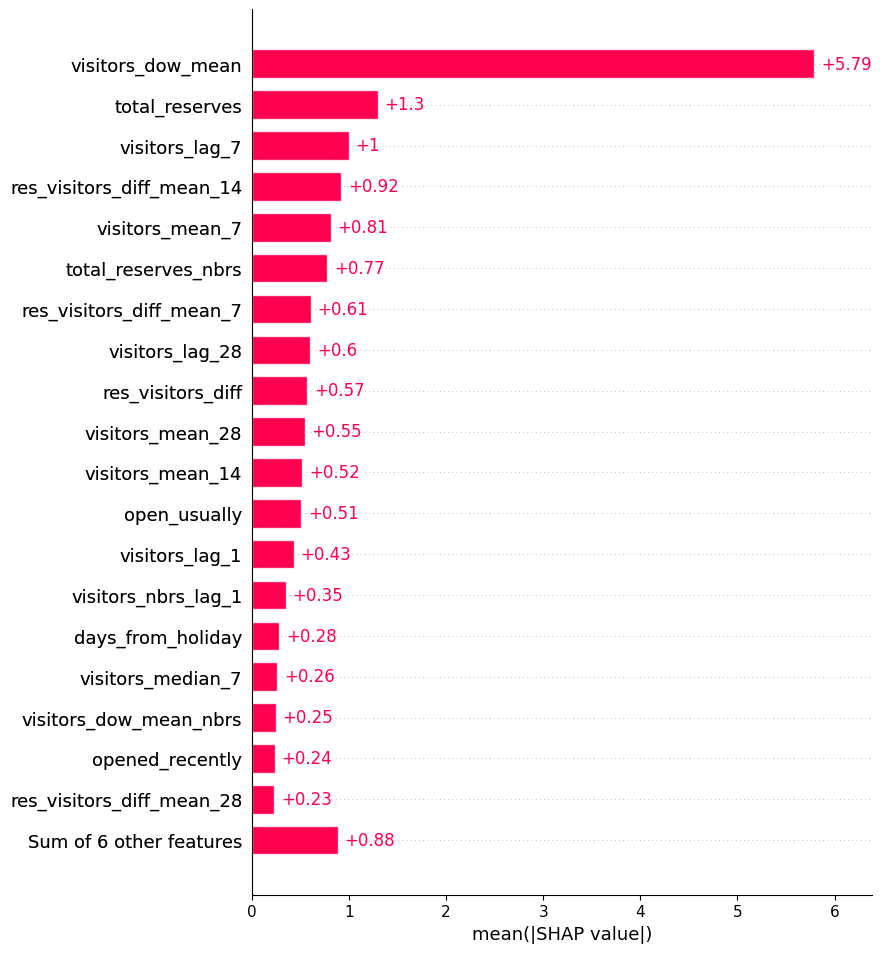

In [26]:
shap.plots.bar(shap_values, max_display=20)

### Visitors per day: actual vs predicted

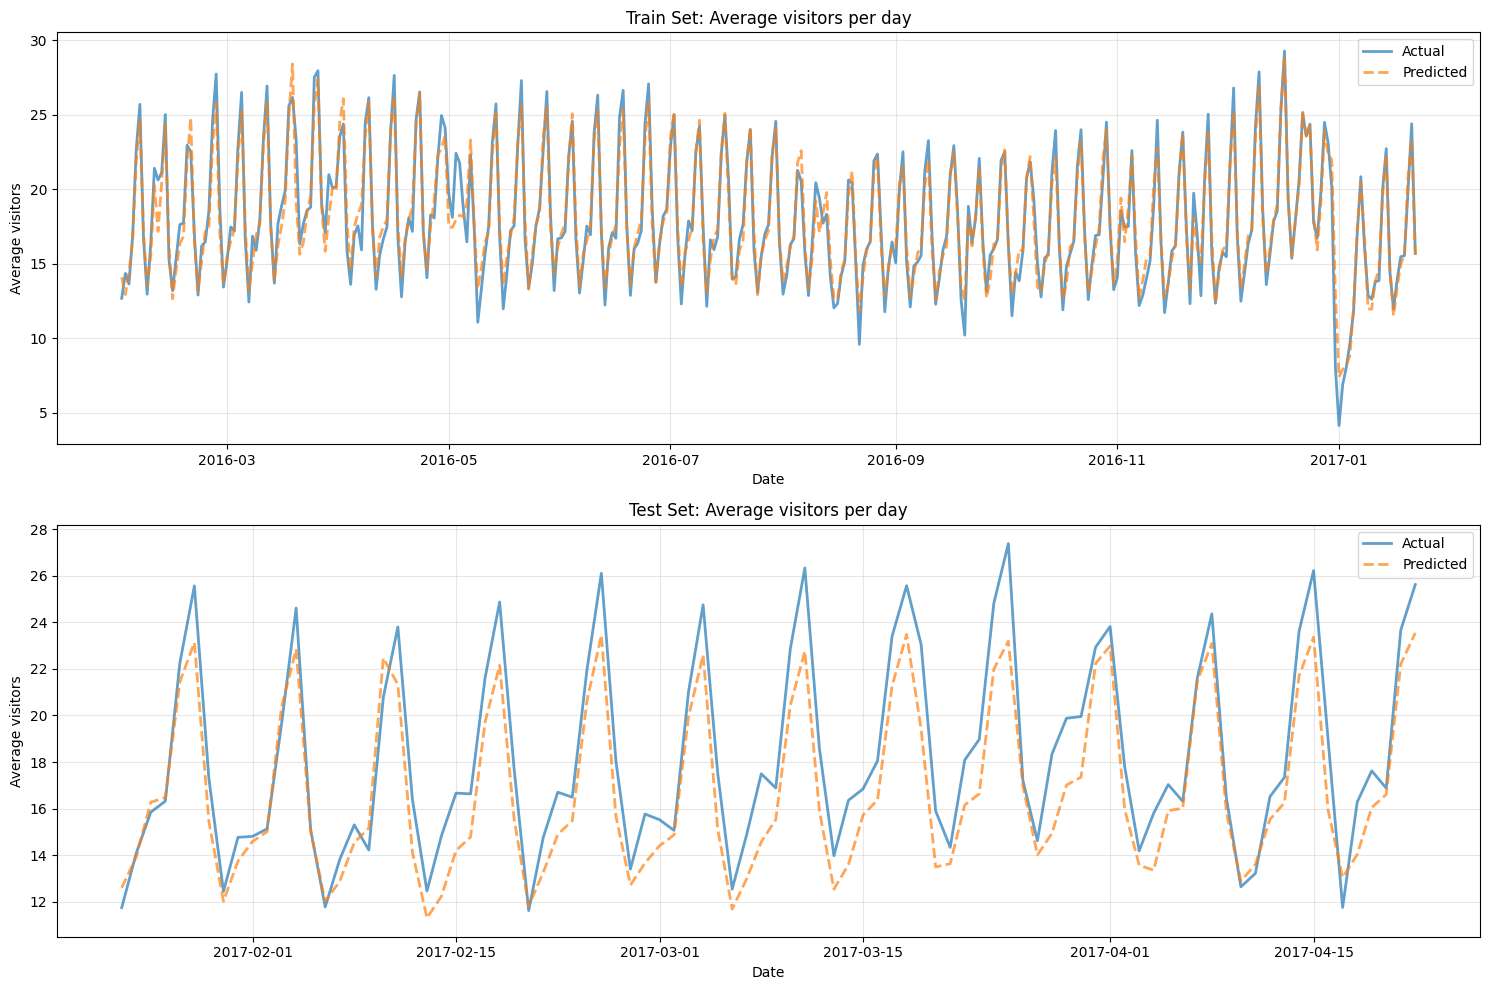

In [27]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [29]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [30]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[5.26643117e-01 3.01494730e-01 9.75423352e+00 5.00992104e+00
 2.28891607e+01 2.51558123e+01 2.78463223e+01 0.00000000e+00
 3.72685821e+01 1.12588490e+00 2.11300470e+01 3.29241536e+00
 2.74334831e+01 4.85917841e+01 2.45717927e+01 4.98454096e+00
 1.33638909e+01 1.11109588e+01 2.45968810e+01 4.82833666e+01
 4.78495847e+00 1.28953032e+01 1.20422868e+01 1.65172149e+01
 1.57874188e+00 2.64977854e+01 1.17397111e+01 1.96523371e+01
 9.26431087e-01 1.37177083e+01 2.07860755e+01 2.29721347e+00
 1.88153830e+01 8.04315194e+00 7.64436755e+00 0.00000000e+00
 5.39802666e-01 3.19844643e+01 2.21978614e+01 1.22796238e+01
 3.62945801e+01 3.66024546e+01 5.15638674e+00 0.00000000e+00
 1.63747121e+01 1.47426035e+01 0.00000000e+00 1.17150

In [31]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [28]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "best_params": convert_to_serializable(study.best_params),
    "best_score": float(study.best_value),
    "std": float(cv_results.sort_values(["rank_test_score"]).iloc[0]["std_test_score"]),
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)